### Downscaling T algorithm dev

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date
from buildforcing.datasets import PNNLSnotel

### SNOTEL missing data
I want to get a sense for how much data is typically missing in the SNOTEL data.

In [2]:
snotel = PNNLSnotel(site_name='Snowslide Canyon', storage_path='C:/Users/clmbn/NMT_PhD/data/snotel/')
snotel.load_data()

In [3]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1997-10-01 to 2021-09-30


In [4]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

In [5]:
# Ensure index is daily
snotel_data = snotel_data.asfreq('D')

In [6]:
# Calculate statistics for the number of sequential missing days in T max
def count_sequential_missing_days(data: np.array) -> tuple:
    '''
    Count the number of sequential missing days in numpy array data. Assumes data is daily over input.
    Returns two lists: streak_lengths and streak_counts.
    '''
    missing_stats = {}
    current_streak = 0
    for day in data:
        if pd.isna(day):
            current_streak += 1
        else:
            if current_streak > 0:
                if current_streak in missing_stats:
                    missing_stats[current_streak] += 1
                else:
                    missing_stats[current_streak] = 1
            current_streak = 0
    # Check if there was a streak at the end of the data
    if current_streak > 0:
        if current_streak in missing_stats:
            missing_stats[current_streak] += 1
        else:
            missing_stats[current_streak] = 1

    # Sort the output dictionary by keys (number of missing days)
    missing_stats = dict(sorted(missing_stats.items()))
    # Convert keys and values to lists
    streak_lengths = list(missing_stats.keys())
    streak_counts = list(missing_stats.values())
    return streak_lengths, streak_counts

Streak lengths: [1, 2, 3]
Streak counts: [1, 1, 1]


<BarContainer object of 3 artists>

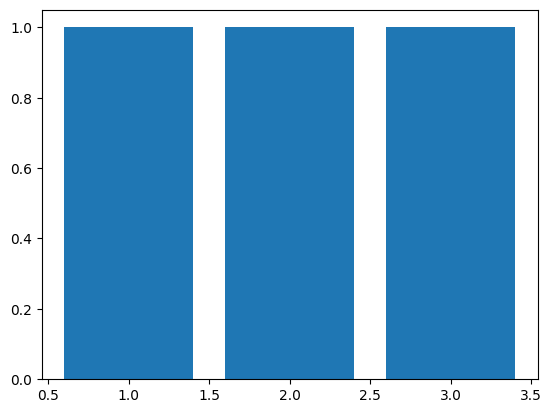

In [7]:
# Test the function
test_data = np.array([1, 2, np.nan, np.nan, 3, np.nan, 4, np.nan, np.nan, np.nan])
streaks, streak_counts = count_sequential_missing_days(test_data)
print("Streak lengths:", streaks)
print("Streak counts:", streak_counts)
plt.bar(streaks, streak_counts)

Max T streaks: [1, 2, 3, 4, 22]
Max T counts: [19, 50, 2, 1, 1]
Min T streaks: [1, 2, 3, 4, 22]
Min T counts: [22, 50, 2, 2, 1]


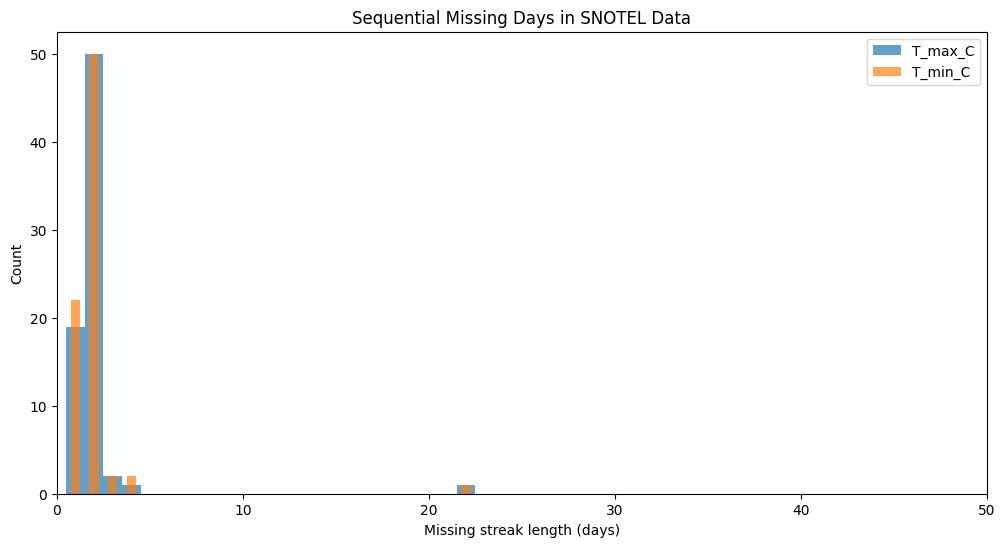

In [8]:
streaks_max, streak_counts_max = count_sequential_missing_days(snotel_data['T_max_C'].values)
streaks_min, streak_counts_min = count_sequential_missing_days(snotel_data['T_min_C'].values)

#Print the results
print("Max T streaks:", streaks_max)
print("Max T counts:", streak_counts_max)
print("Min T streaks:", streaks_min)
print("Min T counts:", streak_counts_min)

plt.figure(figsize=(12, 6))
plt.bar(streaks_max, streak_counts_max, width=1.0, alpha=0.7, label='T_max_C')
plt.bar(streaks_min, streak_counts_min, width=0.5, alpha=0.7, label='T_min_C')
plt.xlim(0, 50)
plt.xlabel('Missing streak length (days)')
plt.ylabel('Count')
plt.legend()
plt.title('Sequential Missing Days in SNOTEL Data')
plt.show()




Text(0.5, 1.0, 'SNOTEL Temperature Data')

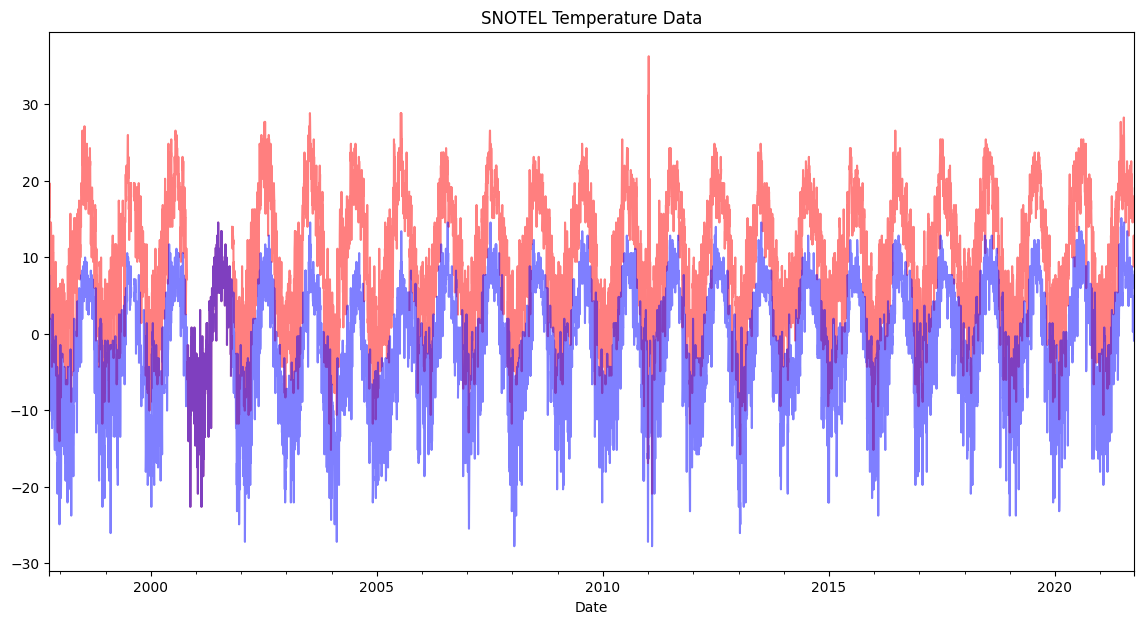

In [9]:
# Plot T max and T min data
plt.figure(figsize=(14, 7))
snotel_data['T_max_C'].plot(label='T_max_C', color='red', alpha=0.5)
snotel_data['T_min_C'].plot(label='T_min_C', color='blue', alpha=0.5)
plt.title('SNOTEL Temperature Data')

In [10]:
snotel_data['2000-12-01':'2000-12-31'].head(20)


,T_max_C,T_min_C,T_avg_C,precip_mm,swe_mm
Date,,,,,
2000-12-01 00:00:00-07:00,0.244444,0.244444,0.244444,0.00,180.34
2000-12-02 00:00:00-07:00,-7.766667,-7.766667,-7.766667,0.00,180.34
2000-12-03 00:00:00-07:00,-10.055556,-10.055556,-10.055556,0.00,180.34
2000-12-04 00:00:00-07:00,-6.050000,-6.050000,-6.050000,0.00,180.34
2000-12-05 00:00:00-07:00,-0.900000,-0.900000,-0.900000,2.54,180.34
2000-12-06 00:00:00-07:00,-3.761111,-3.761111,-3.761111,0.00,182.88
2000-12-07 00:00:00-07:00,-1.472222,-1.472222,-1.472222,2.54,182.88
2000-12-08 00:00:00-07:00,-4.905556,-4.905556,-4.905556,2.54,185.42
2000-12-09 00:00:00-07:00,-2.616667,-2.616667,-2.616667,0.00,187.96


In [11]:
# print latitude and longitude
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 35.34, Longitude: -111.65
